In [1]:
!python --version

Python 3.10.12


## **Table 96. Data ingestion from FRED**

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime as dt
import pandas_datareader as pdr

stocks = ['CL=F']
market_index = '^GSPC'


start = dt.datetime(2010, 1, 1)
end = dt.datetime(2024,1,1)

data = yf.download(stocks + [market_index], start='2010-01-01', end='2024-01-01', interval='1mo')['Adj Close']

data.index = pd.to_datetime(data.index)
data.reset_index(inplace=True)

# Total Consumer Credit Owned and Securitized from FRED
cpiaucsl = pdr.get_data_fred('CPIAUCSL', start=start, end=end)
cpiaucsl.reset_index(inplace=True)

# 3-month Treasury Bill rate (risk-free rate) from FRED
dgs3mo = pdr.get_data_fred('DGS3MO', start=start, end=end)
dgs3mo = dgs3mo.resample('ME').last() / 100  # Convert to monthly frequency and from percentage to decima
dgs3mo.reset_index(inplace=True)

# 10-year Treasury Bill rate (risk-free rate) from FRED
DGS10 = pdr.get_data_fred('DGS10', start=start, end=end)
DGS10 = DGS10.resample('ME').last() / 100  # Convert to monthly frequency and from percentage to decimal
DGS10.reset_index(inplace=True)

# GDP from FRED
gdp = pdr.get_data_fred('GDP', start=start, end=end)
gdp = gdp.resample('ME').bfill().ffill()
gdp.reset_index(inplace=True)

# Example: Federal Funds Rate
interest_rate = pdr.get_data_fred('FEDFUNDS', start=start, end=end)
interest_rate = interest_rate.resample('ME').last()  # Ensure monthly frequency
interest_rate.reset_index(inplace=True)

# industrial production from FRED
indpro = pdr.get_data_fred('INDPRO', start=start, end=end)
indpro.reset_index(inplace=True)

# Total Consumer Credit Owned and Securitized from FRED
totalsl = pdr.get_data_fred('TOTALSL', start=start, end=end)
totalsl.reset_index(inplace=True)

money_supply = pdr.get_data_fred('M2SL', start=start, end=end)
money_supply['Lagged_MoneySupply'] = money_supply['M2SL'].shift(1)
money_supply.reset_index(inplace=True)

unemployment_rate = pdr.get_data_fred('UNRATE', start, end)
unemployment_rate.reset_index(inplace=True)

data = pd.concat([data, cpiaucsl['CPIAUCSL'], dgs3mo['DGS3MO'], DGS10['DGS10'], gdp['GDP'],
           indpro['INDPRO'], totalsl['TOTALSL'], money_supply['Lagged_MoneySupply'],
                  interest_rate['FEDFUNDS'], unemployment_rate['UNRATE']], axis=1)
data = data.set_index('Date')
print(data.head())

[*********************100%***********************]  2 of 2 completed


                 CL=F        ^GSPC  CPIAUCSL  DGS3MO   DGS10        GDP  \
Date                                                                      
2010-01-01  72.889999  1073.869995   217.488  0.0008  0.0363  14980.193   
2010-02-01  79.660004  1104.489990   217.281  0.0013  0.0361  14980.193   
2010-03-01  83.760002  1169.430054   217.353  0.0016  0.0384  14980.193   
2010-04-01  86.150002  1186.689941   217.403  0.0016  0.0369  15141.607   
2010-05-01  73.970001  1089.410034   217.290  0.0016  0.0331  15141.607   

             INDPRO     TOTALSL  Lagged_MoneySupply  FEDFUNDS  UNRATE  
Date                                                                   
2010-01-01  89.1897  2543.50802                 NaN      0.11     9.8  
2010-02-01  89.5046  2530.02428              8478.0      0.13     9.8  
2010-03-01  90.1356  2536.55195              8527.6      0.16     9.9  
2010-04-01  90.4607  2532.76479              8523.7      0.20     9.9  
2010-05-01  91.7014  2521.68794           

## **Table 97. Data transformation**

In [3]:
df = pd.DataFrame()
df['wti_ExcessReturns'] = np.log(data['CL=F']).diff() - data['DGS3MO']
df['SP_ExcessReturns'] = np.log(data['^GSPC']).diff() - data['DGS3MO']
df['inflation'] = (data['CPIAUCSL'].diff() / data['CPIAUCSL'].shift(1)) * 100
df['ConsumerCredit'] = data['TOTALSL'] - data['TOTALSL'].shift(1)
df['yieldSpread'] = data['DGS10'] - data['DGS3MO']
df['GDP'] = np.log(data['GDP']).diff()
df['InterestRate'] = data['FEDFUNDS']
df['Lagged_MoneySupply'] = np.log(data['Lagged_MoneySupply']).diff()
df['unemployment_rate'] =  data['UNRATE'].shift(1)
df.dropna(inplace=True)
print(df.head())

            wti_ExcessReturns  SP_ExcessReturns  inflation  ConsumerCredit  \
Date                                                                         
2010-03-01           0.048588          0.055533   0.033137         6.52767   
2010-04-01           0.026534          0.013051   0.023004        -3.78716   
2010-05-01          -0.154030         -0.087132  -0.051977       -11.07685   
2010-06-01           0.020393         -0.057188  -0.041880        -3.27153   
2010-07-01           0.041462          0.065016   0.186925         2.68839   

            yieldSpread       GDP  InterestRate  Lagged_MoneySupply  \
Date                                                                  
2010-03-01       0.0368  0.000000          0.16            0.005833   
2010-04-01       0.0353  0.010718          0.20           -0.000457   
2010-05-01       0.0315  0.000000          0.20            0.003677   
2010-06-01       0.0279  0.000000          0.18            0.006315   
2010-07-01       0.0279  0.

## **Table 98 Stationarity check using ADF test**

In [4]:
from statsmodels.tsa.stattools import adfuller

variables = ['GDP', 'InterestRate', 'Lagged_MoneySupply']

# ADF Test
adf_results = []
for var in variables:
    adf_result = adfuller(df[var])
    adf_results.append([var, adf_result[0], adf_result[1], adf_result[4]['1%'],
                        adf_result[4]['5%'], adf_result[4]['10%'],
                        'Yes' if adf_result[1] < 0.05 else 'No'])

adf_table = pd.DataFrame(adf_results, columns=['Variable', 'Statistic', 'p-value',
                                               'Critical Value (1%)', 'Critical Value (5%)',
                                               'Critical Value (10%)', 'Stationary (ADF)'])

print("ADF Test Results")
display(adf_table)

ADF Test Results


,Variable,Statistic,p-value,Critical Value (1%),Critical Value (5%),Critical Value (10%),Stationary (ADF)
0,GDP,-2.216898,0.200170,-3.491818,-2.888444,-2.581120,No
1,InterestRate,-1.331398,0.614688,-3.488535,-2.887020,-2.580360,No
2,Lagged_MoneySupply,-5.545198,0.000002,-3.487022,-2.886363,-2.580009,Yes


## **Table 99. Data transformation and recheck stationarity on the transformed variables**

In [5]:
variables = ['GDP', 'InterestRate']

for var in variables:
    df[f'{var}_diff'] = df[var].diff()
df.dropna(inplace=True)

adf_results = []
for var in variables:
    adf_result = adfuller(df[f'{var}_diff'])
    adf_results.append([var, adf_result[0], adf_result[1], adf_result[4]['1%'],
                        adf_result[4]['5%'], adf_result[4]['10%'],
                        'Yes' if adf_result[1] < 0.05 else 'No'])

adf_table = pd.DataFrame(adf_results, columns=['Variable', 'Statistic', 'p-value',
                                               'Critical Value (1%)', 'Critical Value (5%)',
                                               'Critical Value (10%)', 'Stationary (ADF)'])

print("ADF Test Results (After Stationarizing)")
display(adf_table)

ADF Test Results (After Stationarizing)


,Variable,Statistic,p-value,Critical Value (1%),Critical Value (5%),Critical Value (10%),Stationary (ADF)
0,GDP,-4.767404,0.000063,-3.491818,-2.888444,-2.58112,Yes
1,InterestRate,-3.377035,0.011767,-3.488535,-2.887020,-2.58036,Yes


In [6]:
df.columns

Index(['wti_ExcessReturns', 'SP_ExcessReturns', 'inflation', 'ConsumerCredit',
       'yieldSpread', 'GDP', 'InterestRate', 'Lagged_MoneySupply',
       'unemployment_rate', 'GDP_diff', 'InterestRate_diff'],
      dtype='object')

## **Table 100. 2SLS implementation**

In [ ]:
!pip install linearmodels

In [8]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from linearmodels import IV2SLS

In [9]:
df.columns

Index(['wti_ExcessReturns', 'SP_ExcessReturns', 'inflation', 'ConsumerCredit',
       'yieldSpread', 'GDP', 'InterestRate', 'Lagged_MoneySupply',
       'unemployment_rate', 'GDP_diff', 'InterestRate_diff'],
      dtype='object')

In [10]:
# 〖InterestRate〗_t = π_0 + π_1 *〖MoneySupply〗_(t-1) + v_t
print("Step 1: Regress InterestRate_diff on Lagged_MoneySupply (Instrument)")
print()
X_stage1 = sm.add_constant(df['Lagged_MoneySupply'])  # Add intercept
stage1_model = sm.OLS(df['InterestRate_diff'], X_stage1).fit()
print(stage1_model.summary())

# Predicted values (fitted values for InterestRate_diff)
df['InterestRate_pred'] = stage1_model.predict(X_stage1)

print()
print()

# 〖GDP〗_t = α + β *〖InterestRate^〗_t + ϵ_t
print("Step 2: Regress GDP_diff on the predicted InterestRate_diff (instrumented) and exogenous variables")
print()
X_stage2 = sm.add_constant(df['InterestRate_pred'])
stage2_model = sm.OLS(df['GDP_diff'], X_stage2).fit()
print(stage2_model.summary())

Step 1: Regress InterestRate_diff on Lagged_MoneySupply (Instrument)

                            OLS Regression Results                            
Dep. Variable:      InterestRate_diff   R-squared:                       0.355
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     63.90
Date:                Thu, 19 Dec 2024   Prob (F-statistic):           1.08e-12
Time:                        04:26:12   Log-Likelihood:                 28.776
No. Observations:                 118   AIC:                            -53.55
Df Residuals:                     116   BIC:                            -48.01
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

In [11]:
df.columns

Index(['wti_ExcessReturns', 'SP_ExcessReturns', 'inflation', 'ConsumerCredit',
       'yieldSpread', 'GDP', 'InterestRate', 'Lagged_MoneySupply',
       'unemployment_rate', 'GDP_diff', 'InterestRate_diff',
       'InterestRate_pred'],
      dtype='object')

In [12]:
df[['GDP_diff','InterestRate_diff','Lagged_MoneySupply']].corr()

,GDP_diff,InterestRate_diff,Lagged_MoneySupply
GDP_diff,1.000000,-0.005093,-0.005377
InterestRate_diff,-0.005093,1.000000,-0.595975
Lagged_MoneySupply,-0.005377,-0.595975,1.000000


In [13]:
df.columns


Index(['wti_ExcessReturns', 'SP_ExcessReturns', 'inflation', 'ConsumerCredit',
       'yieldSpread', 'GDP', 'InterestRate', 'Lagged_MoneySupply',
       'unemployment_rate', 'GDP_diff', 'InterestRate_diff',
       'InterestRate_pred'],
      dtype='object')

## **Table 101. Stationarity test on relevant variables ('wti_ExcessReturns', 'SP_ExcessReturns', 'ConsumerCredit','inflation')**

In [14]:
from tabulate import tabulate

variables = [
    'wti_ExcessReturns', 'SP_ExcessReturns', 'ConsumerCredit','inflation']

results = {}
for var in variables:
    series = df[var].dropna()
    adf_test = adfuller(series, autolag='AIC')
    results[var] = {
        'ADF Statistic': adf_test[0],
        'p-value': adf_test[1],
        'Critical Values': adf_test[4],
        'Stationary': 'Yes' if adf_test[1] <= 0.05 else 'No'}

table_data = []
for var, result in results.items():
    table_data.append([
        var,
        result['ADF Statistic'],
        result['p-value'],
        result['Stationary']])

headers = ['Variable', 'ADF Statistic', 'p-value', 'Stationary']
table = tabulate(table_data, headers=headers, tablefmt='fancy_grid')
print(table)

╒═══════════════════╤═════════════════╤═════════════╤══════════════╕
│ Variable          │   ADF Statistic │     p-value │ Stationary   │
╞═══════════════════╪═════════════════╪═════════════╪══════════════╡
│ wti_ExcessReturns │       -10.019   │ 1.69816e-17 │ Yes          │
├───────────────────┼─────────────────┼─────────────┼──────────────┤
│ SP_ExcessReturns  │        -2.95141 │ 0.0396879   │ Yes          │
├───────────────────┼─────────────────┼─────────────┼──────────────┤
│ ConsumerCredit    │        -9.67765 │ 1.2285e-16  │ Yes          │
├───────────────────┼─────────────────┼─────────────┼──────────────┤
│ inflation         │        -2.76108 │ 0.0640526   │ No           │
╘═══════════════════╧═════════════════╧═════════════╧══════════════╛


## **Table 102. Transform non-stationary variables and retest to ensure stationarity**

In [15]:
non_stationary_vars = ['inflation']

for var in non_stationary_vars:
    df[f'{var}_diff'] = df[var].diff()

results_diff = {}
for var in non_stationary_vars:
    series = df[f'{var}_diff'].dropna()
    adf_test = adfuller(series, autolag='AIC')
    results_diff[var] = {
        'ADF Statistic': adf_test[0],
        'p-value': adf_test[1],
        'Critical Values': adf_test[4],
        'Stationary': 'Yes' if adf_test[1] <= 0.05 else 'No'}

table_data_diff = []
for var, result in results_diff.items():
    table_data_diff.append([
        var + '_diff',
        result['ADF Statistic'],
        result['p-value'],
        result['Stationary']])

headers_diff = ['Variable', 'ADF Statistic', 'p-value', 'Stationary']
colalign = ["left", "decimal", "decimal", "center"]
table_diff = tabulate(table_data_diff, headers=headers_diff, tablefmt='fancy_grid', colalign=colalign)

print(table_diff)

╒════════════════╤═════════════════╤═════════════╤══════════════╕
│ Variable       │   ADF Statistic │     p-value │  Stationary  │
╞════════════════╪═════════════════╪═════════════╪══════════════╡
│ inflation_diff │        -8.63004 │ 5.78861e-14 │     Yes      │
╘════════════════╧═════════════════╧═════════════╧══════════════╛


In [16]:
df.columns

Index(['wti_ExcessReturns', 'SP_ExcessReturns', 'inflation', 'ConsumerCredit',
       'yieldSpread', 'GDP', 'InterestRate', 'Lagged_MoneySupply',
       'unemployment_rate', 'GDP_diff', 'InterestRate_diff',
       'InterestRate_pred', 'inflation_diff'],
      dtype='object')

## **Table 103. Pearson's correlation test**

In [17]:
df[['SP_ExcessReturns', 'ConsumerCredit', 'inflation', 'wti_ExcessReturns']].corr()

,SP_ExcessReturns,ConsumerCredit,inflation,wti_ExcessReturns
SP_ExcessReturns,1.000000,0.114949,0.108265,0.408615
ConsumerCredit,0.114949,1.000000,0.293373,0.025029
inflation,0.108265,0.293373,1.000000,0.227421
wti_ExcessReturns,0.408615,0.025029,0.227421,1.000000


## **Table 104. Two Stage Least Squares using 〖Inflation〗_t=α_0+α_1 C〖L_ExcessReturns〗_t+α_2 〖ConsumerCredit〗_t+ε_1 t and 〖CL_ExcessReturns〗_t=β_0+β_1 〖SP_ExcessReturns〗_t+β_2 〖Inflation〗_t+β_3 C〖onsumerCredit〗_t+ε_2 t**

In [18]:
df.dropna(inplace=True)

endog1 = df['inflation_diff']
endog2 = df['wti_ExcessReturns']

exog1 = df[['ConsumerCredit']]
exog2 = df[['SP_ExcessReturns']]

instr1 = df[['SP_ExcessReturns', 'ConsumerCredit']]  # Instruments for CL_ExcessReturns
instr2 = df[['SP_ExcessReturns', 'ConsumerCredit']]  # Instruments for Inflation

# First Stage: Predict endogenous variables"
model1_stage1 = sm.OLS(endog2, sm.add_constant(instr1)).fit()
predicted_cl_excess_returns = model1_stage1.predict(sm.add_constant(instr1))
model2_stage1 = sm.OLS(endog1, sm.add_constant(instr2)).fit()
# Predict Inflation
predicted_inflation = model2_stage1.predict(sm.add_constant(instr2))

# Second Stage: Use predicted values in original equations")
# Inflation Equation
model1_stage2 = sm.OLS(endog1, sm.add_constant(pd.concat([pd.Series(predicted_cl_excess_returns,
                                                                    name='CL_ExcessReturns'), exog1], axis=1))).fit()
# wti_ExcessReturns Equation
model2_stage2 = sm.OLS(endog2, sm.add_constant(pd.concat([pd.Series(predicted_inflation,
                                                                    name='Inflation'), exog2], axis=1))).fit()

print("Inflation Equation Results:")
print(model1_stage2.summary())

print("\nCL_ExcessReturns Equation Results:")
print(model2_stage2.summary())

Inflation Equation Results:
                            OLS Regression Results                            
Dep. Variable:         inflation_diff   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     1.726
Date:                Thu, 19 Dec 2024   Prob (F-statistic):              0.183
Time:                        04:26:13   Log-Likelihood:               -0.72298
No. Observations:                 117   AIC:                             7.446
Df Residuals:                     114   BIC:                             15.73
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const       

In [19]:
df.columns

Index(['wti_ExcessReturns', 'SP_ExcessReturns', 'inflation', 'ConsumerCredit',
       'yieldSpread', 'GDP', 'InterestRate', 'Lagged_MoneySupply',
       'unemployment_rate', 'GDP_diff', 'InterestRate_diff',
       'InterestRate_pred', 'inflation_diff'],
      dtype='object')

## **Table 105. Granger causality test**

In [20]:
from statsmodels.tsa.stattools import grangercausalitytests

max_lag = 6
variables = ['SP_ExcessReturns', 'inflation_diff', 'ConsumerCredit', 'wti_ExcessReturns']

p_values = {}

for var in variables:
    test_result = grangercausalitytests(df[['wti_ExcessReturns', var]], maxlag=max_lag)
    p_values[var] = [round(test_result[i+1][0]['ssr_ftest'][1], 4) for i in range(max_lag)]

granger_summary = pd.DataFrame(p_values, index=[f'lag_{i+1}' for i in range(max_lag)])
granger_summary


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.4064  , p=0.2381  , df_denom=113, df_num=1
ssr based chi2 test:   chi2=1.4437  , p=0.2295  , df=1
likelihood ratio test: chi2=1.4348  , p=0.2310  , df=1
parameter F test:         F=1.4064  , p=0.2381  , df_denom=113, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.6979  , p=0.4998  , df_denom=110, df_num=2
ssr based chi2 test:   chi2=1.4593  , p=0.4821  , df=2
likelihood ratio test: chi2=1.4501  , p=0.4843  , df=2
parameter F test:         F=0.6979  , p=0.4998  , df_denom=110, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.9134  , p=0.4372  , df_denom=107, df_num=3
ssr based chi2 test:   chi2=2.9193  , p=0.4042  , df=3
likelihood ratio test: chi2=2.8826  , p=0.4101  , df=3
parameter F test:         F=0.9134  , p=0.4372  , df_denom=107, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.9386  , p=0.4447  

,SP_ExcessReturns,inflation_diff,ConsumerCredit,wti_ExcessReturns
lag_1,0.2381,0.6978,0.7969,1.0
lag_2,0.4998,0.9193,0.9728,1.0
lag_3,0.4372,0.9498,0.5121,1.0
lag_4,0.4447,0.9426,0.5959,1.0
lag_5,0.3774,0.7186,0.6725,1.0
lag_6,0.3538,0.6938,0.7209,1.0


## **Table 106. Augmented Dicky-Fuller test of stationarity on ^GSPC daily series**

In [21]:
ticker = "^GSPC"
start_date = "2010-01-01"
end_date = "2024-01-01"

sp_data= yf.download(ticker, start=start_date, end=end_date)['Adj Close']
print(sp_data.head())

[*********************100%***********************]  1 of 1 completed

Ticker            ^GSPC
Date                   
2010-01-04  1132.989990
2010-01-05  1136.520020
2010-01-06  1137.140015
2010-01-07  1141.689941
2010-01-08  1144.979980


In [22]:
from tabulate import tabulate
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(sp_data)

table_data = []
stationary = 'Yes' if adf_result[1] <= 0.05 else 'No'
table_data.append([
    'sp',
    adf_result[0],
    adf_result[1],
    stationary])

headers = ['Variable', 'ADF Statistic', 'p-value', 'Stationary']
table = tabulate(table_data, headers=headers, tablefmt='fancy_grid')
print(table)

╒════════════╤═════════════════╤═══════════╤══════════════╕
│ Variable   │   ADF Statistic │   p-value │ Stationary   │
╞════════════╪═════════════════╪═══════════╪══════════════╡
│ sp         │        0.243395 │  0.974593 │ No           │
╘════════════╧═════════════════╧═══════════╧══════════════╛


## **Table 107. GDP data differencing and retest for stationarity**

In [23]:
sp = np.log(sp_data).diff().dropna()
adf_result = adfuller(sp)

table_data = []
stationary = 'Yes' if adf_result[1] <= 0.05 else 'No'
table_data.append([
    'sp',
    adf_result[0],
    adf_result[1],
    stationary])

headers = ['Variable', 'ADF Statistic', 'p-value', 'Stationary']
table = tabulate(table_data, headers=headers, tablefmt='fancy_grid')
print(table)

╒════════════╤═════════════════╤═════════════╤══════════════╕
│ Variable   │   ADF Statistic │     p-value │ Stationary   │
╞════════════╪═════════════════╪═════════════╪══════════════╡
│ sp         │        -12.9088 │ 4.09798e-24 │ Yes          │
╘════════════╧═════════════════╧═════════════╧══════════════╛


## **Table 108. Optimal AR lag order (p) identification**

In [24]:
from statsmodels.tsa.ar_model import ar_select_order
import warnings
warnings.filterwarnings('ignore')

select_model = ar_select_order(sp_data, maxlag=12)
print(select_model.ar_lags)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## **Table 109. Auto Regressive model refit AutoReg[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]**

In [25]:
from statsmodels.tsa.ar_model import AutoReg

optimal_lags = select_model.ar_lags
ar_model = AutoReg(sp, lags=optimal_lags)
results = ar_model.fit()
print(results.summary())

                            AutoReg Model Results                             
Dep. Variable:                  ^GSPC   No. Observations:                 3521
Model:                    AutoReg(10)   Log Likelihood               10905.209
Method:               Conditional MLE   S.D. of innovations              0.011
Date:                Thu, 19 Dec 2024   AIC                         -21786.418
Time:                        04:26:14   BIC                         -21712.454
Sample:                            10   HQIC                        -21760.025
                                 3521                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      2.426      0.015     8.6e-05       0.001
^GSPC.L1      -0.0945      0.017     -5.601      0.000      -0.128      -0.061
^GSPC.L2       0.0504      0.017      2.982      0.0

# **Kyock Transformation**

In [26]:
df.columns

Index(['wti_ExcessReturns', 'SP_ExcessReturns', 'inflation', 'ConsumerCredit',
       'yieldSpread', 'GDP', 'InterestRate', 'Lagged_MoneySupply',
       'unemployment_rate', 'GDP_diff', 'InterestRate_diff',
       'InterestRate_pred', 'inflation_diff'],
      dtype='object')

## **Table 110. Unit root testing**

In [27]:
from tabulate import tabulate
from statsmodels.tsa.stattools import adfuller

columns_to_test = ['inflation', 'unemployment_rate']

table_data = []
for column in columns_to_test:
    result = adfuller(df[column])
    stationary = 'Yes' if result[1] <= 0.05 else 'No'  # Determine stationarity
    table_data.append([column, result[0], result[1], stationary])

headers = ['Variable', 'ADF Statistic', 'p-value', 'Stationary']
table = tabulate(table_data, headers=headers, tablefmt='fancy_grid')
print(table)

╒═══════════════════╤═════════════════╤═══════════╤══════════════╕
│ Variable          │   ADF Statistic │   p-value │ Stationary   │
╞═══════════════════╪═════════════════╪═══════════╪══════════════╡
│ inflation         │         -2.6804 │ 0.0774924 │ No           │
├───────────────────┼─────────────────┼───────────┼──────────────┤
│ unemployment_rate │         -2.8357 │ 0.0533528 │ No           │
╘═══════════════════╧═════════════════╧═══════════╧══════════════╛


## **Table 111. Data staionarize and apply lag**

In [28]:
df['inflation_diff'] = df['inflation'].diff()
df['unemployment_rate_diff'] = df['unemployment_rate'].diff()
df['inflation_diff_lag'] = df['inflation_diff'].shift(1)  # Lag of 1 period
df['unemployment_rate_lag'] = df['unemployment_rate_diff'].shift(1)  # Lag of 1 period (you can adjust the lag)
df.dropna(inplace=True)

columns_to_test = ['inflation_diff', 'unemployment_rate_diff', 'inflation_diff_lag', 'unemployment_rate_lag']

table_data = []
for column in columns_to_test:
    result = adfuller(df[column])
    stationary = 'Yes' if result[1] <= 0.05 else 'No'
    table_data.append([column, result[0], result[1], stationary])

headers = ['Variable', 'ADF Statistic', 'p-value', 'Stationary']
table = tabulate(table_data, headers=headers, tablefmt='fancy_grid')
print(table)

╒════════════════════════╤═════════════════╤═════════════╤══════════════╕
│ Variable               │   ADF Statistic │     p-value │ Stationary   │
╞════════════════════════╪═════════════════╪═════════════╪══════════════╡
│ inflation_diff         │        -8.6858  │ 4.16693e-14 │ Yes          │
├────────────────────────┼─────────────────┼─────────────┼──────────────┤
│ unemployment_rate_diff │       -11.2882  │ 1.40055e-20 │ Yes          │
├────────────────────────┼─────────────────┼─────────────┼──────────────┤
│ inflation_diff_lag     │        -8.49917 │ 1.25183e-13 │ Yes          │
├────────────────────────┼─────────────────┼─────────────┼──────────────┤
│ unemployment_rate_lag  │       -11.2809  │ 1.45695e-20 │ Yes          │
╘════════════════════════╧═════════════════╧═════════════╧══════════════╛


## **Table 112. Koyck model fit and extract Koyck parameters**

In [29]:
import pandas as pd
import statsmodels.api as sm

Y = df['unemployment_rate']
X = sm.add_constant(df['unemployment_rate_lag'])
model_univariate = sm.OLS(Y, X).fit()

print(model_univariate.summary())

                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     4.422
Date:                Thu, 19 Dec 2024   Prob (F-statistic):             0.0377
Time:                        04:26:14   Log-Likelihood:                -256.08
No. Observations:                 115   AIC:                             516.2
Df Residuals:                     113   BIC:                             521.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     5.90

In [30]:
# Extract the Koyck parameters
alpha = model_univariate.params[0] / (1 - model_univariate.params[1])
lamda = model_univariate.params[1]

print(f"Alpha (long-run equilibrium): {alpha:.4f}")
print(f"Lambda (decay parameter): {lamda:.4f}")

Alpha (long-run equilibrium): 9.8143
Lambda (decay parameter): 0.3981


## **Table 113. Geometric Decay of Lagged Effects**

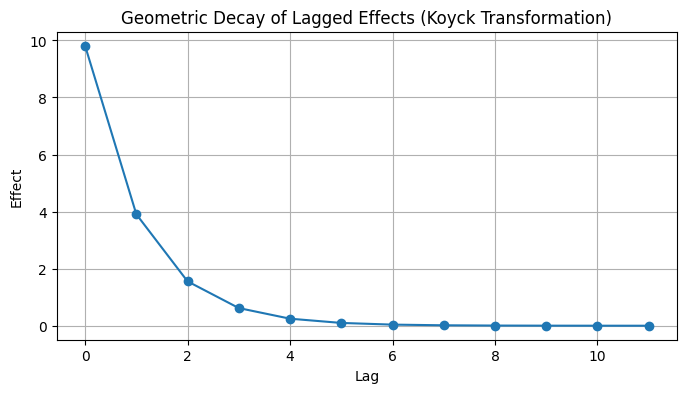

In [31]:
from matplotlib import pyplot as plt
import numpy as np

lags = np.arange(12)

def koyck_decay(lags, alpha, lamda):
    return alpha * (lamda ** lags)

plt.figure(figsize=(8, 4))
plt.plot(lags, koyck_decay(lags, alpha, lamda), marker='o', linestyle='-')
plt.title('Geometric Decay of Lagged Effects (Koyck Transformation)')
plt.xlabel('Lag')
plt.ylabel('Effect')
plt.grid(True)
plt.show()

## **Table 114. GDP, CPI and Government expenditure data ingestion and visualization**

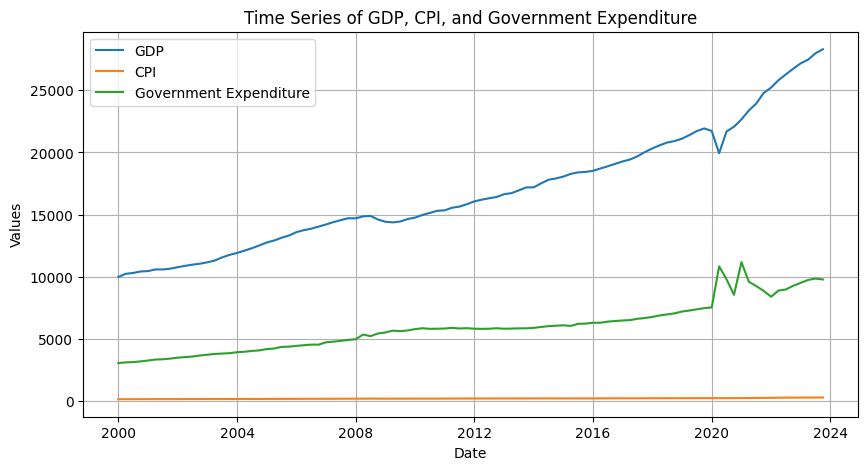

In [32]:
import pandas as pd
import pandas_datareader.data as web
import datetime
import matplotlib.pyplot as plt

start_date = '2000-01-01'
end_date = '2023-12-31'

gdp = web.DataReader('GDP', 'fred', start_date, end_date)
cpi = web.DataReader('CPIAUCSL', 'fred', start_date, end_date)  # Consumer Price Index
exp = web.DataReader('W068RCQ027SBEA', 'fred', start_date, end_date)  # Government Expenditure

data = pd.concat([gdp, cpi, exp], axis=1)
data.columns = ['GDP', 'CPI', 'EXP']
data = data.dropna()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(data.index, data['GDP'], label='GDP')
ax.plot(data.index, data['CPI'], label='CPI')
ax.plot(data.index, data['EXP'], label='Government Expenditure')
ax.set_xlabel('Date')
ax.set_ylabel('Values')
ax.set_title('Time Series of GDP, CPI, and Government Expenditure')
ax.legend()
ax.grid(True)
plt.show()

## **Table 115. ADF tests on GDP, CPI and Government Expenditure series**

In [33]:
adf_results = []
for column in data.columns:
    result = adfuller(data[column].dropna())  #
    adf_results.append([column, result[0], result[1], result[4]['1%'], result[4]['5%'], result[4]['10%']])

adf_table = pd.DataFrame(adf_results, columns=['Variable', 'ADF Statistic', 'p-value', 'Critical Value (1%)',
                                               'Critical Value (5%)', 'Critical Value (10%)'])

adf_table['Stationary'] = adf_table['p-value'].apply(lambda p: 'Yes' if p <= 0.05 else 'No')

table_data = []
for index, row in adf_table.iterrows():
    table_data.append([row['Variable'], row['ADF Statistic'], row['p-value'], row['Stationary']])

headers = ['Variable', 'ADF Statistic', 'p-value', 'Stationary']
table = tabulate(table_data, headers=headers, tablefmt='fancy_grid')
print(table)

╒════════════╤═════════════════╤═══════════╤══════════════╕
│ Variable   │   ADF Statistic │   p-value │ Stationary   │
╞════════════╪═════════════════╪═══════════╪══════════════╡
│ GDP        │        2.78808  │  1        │ No           │
├────────────┼─────────────────┼───────────┼──────────────┤
│ CPI        │        1.91026  │  0.998544 │ No           │
├────────────┼─────────────────┼───────────┼──────────────┤
│ EXP        │        0.564125 │  0.986697 │ No           │
╘════════════╧═════════════════╧═══════════╧══════════════╛


In [34]:
data_diff = data.diff().dropna()
adf_results = []
for column in data_diff.columns:
    result = adfuller(data_diff[column].dropna())  #
    adf_results.append([column, result[0], result[1], result[4]['1%'], result[4]['5%'], result[4]['10%']])

adf_table = pd.DataFrame(adf_results, columns=['Variable', 'ADF Statistic', 'p-value', 'Critical Value (1%)',
                                               'Critical Value (5%)', 'Critical Value (10%)'])

adf_table['Stationary'] = adf_table['p-value'].apply(lambda p: 'Yes' if p <= 0.05 else 'No')

table_data = []
for index, row in adf_table.iterrows():
    table_data.append([row['Variable'], row['ADF Statistic'], row['p-value'], row['Stationary']])

headers = ['Variable', 'ADF Statistic', 'p-value', 'Stationary']
table = tabulate(table_data, headers=headers, tablefmt='fancy_grid')
print(table)

╒════════════╤═════════════════╤═════════════╤══════════════╕
│ Variable   │   ADF Statistic │     p-value │ Stationary   │
╞════════════╪═════════════════╪═════════════╪══════════════╡
│ GDP        │        -9.74654 │ 8.22693e-17 │ Yes          │
├────────────┼─────────────────┼─────────────┼──────────────┤
│ CPI        │        -6.24467 │ 4.60701e-08 │ Yes          │
├────────────┼─────────────────┼─────────────┼──────────────┤
│ EXP        │        -5.43797 │ 2.81766e-06 │ Yes          │
╘════════════╧═════════════════╧═════════════╧══════════════╛


## **Table 116. Select optimal lag order and fit ARDL model**

In [35]:
from statsmodels.tsa.ardl import ARDL, ardl_select_order
lag_selection = ardl_select_order(data['GDP'],
                                  exog=data[['CPI', 'EXP']],
                                  maxlag=4,
                                  maxorder=4)
print("Selected Order:", lag_selection.model.ar_lags)

Selected Order: [1, 2, 3, 4]


In [36]:
ardl_model = lag_selection.model.fit()
print(ardl_model.summary())

                              ARDL Model Results                              
Dep. Variable:                    GDP   No. Observations:                   96
Model:                  ARDL(4, 1, 1)   Log Likelihood                -584.915
Method:               Conditional MLE   S.D. of innovations            139.608
Date:                Thu, 19 Dec 2024   AIC                           1189.831
Time:                        04:26:15   BIC                           1215.049
Sample:                    01-01-2001   HQIC                          1200.009
                         - 10-01-2023                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        787.1769    424.923      1.853      0.068     -57.978    1632.332
GDP.L1         0.7905      0.056     14.024      0.000       0.678       0.903
GDP.L2         0.6803      0.079      8.664      0.0

In [37]:
data.tail()

,GDP,CPI,EXP
DATE,,,
2022-10-01,26734.277,297.863,9287.529
2023-01-01,27164.359,300.356,9521.912
2023-04-01,27453.815,303.032,9751.376
2023-07-01,27967.697,304.628,9866.830
2023-10-01,28296.967,307.531,9791.775


## **Table 117. Sanity check (Original vs fitted GDP) visualization**

Prediction GDP Values:
2024-01-01    27772.258134
2024-04-01    29070.498992
2024-07-01    29707.214610
2024-10-01    31651.038432
2025-01-01    32242.901114
Freq: 3MS, dtype: float64


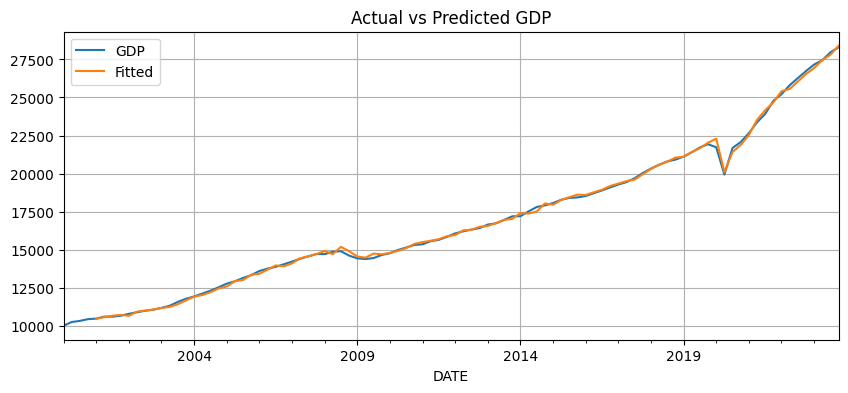

In [38]:
predict = ardl_model.predict(start=len(data), end=len(data) + 4, exog_oos=data[['CPI', 'EXP']])
print("Prediction GDP Values:")
print(predict)

data['Fitted'] = ardl_model.fittedvalues
data[['GDP', 'Fitted']].plot(figsize=(10, 4), title=f"Actual vs Predicted GDP")
plt.grid()
plt.show()

## **Table 118. Forecast future GDP values**

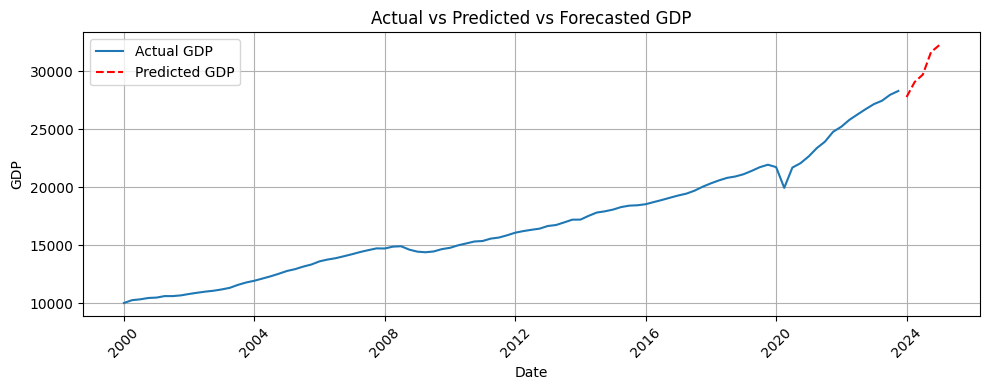

In [39]:
predict_df = pd.DataFrame(predict, columns=['Predicted_GDP'])
predict_df.index = pd.to_datetime(predict_df.index)

combined_data = pd.concat([data[['GDP', 'Fitted']], predict_df], axis=0)
combined_data = combined_data.rename(columns={'GDP': 'Actual_GDP'})

plt.figure(figsize=(10, 4))
plt.plot(combined_data.index, combined_data['Actual_GDP'], label='Actual GDP')
plt.plot(combined_data.index, combined_data['Predicted_GDP'], label='Predicted GDP', linestyle='--', color='red')
plt.xlabel('Date')
plt.ylabel('GDP')
plt.title('Actual vs Predicted vs Forecasted GDP')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Auto Regressive Moving Average**

In [40]:
import pandas_datareader.data as web

start_date = '2010-01-01'
end_date = '2023-12-31'
gdp = web.DataReader('GDP', 'fred', start_date, end_date)
gdp.index = pd.to_datetime(gdp.index)
gdp.head()

,GDP
DATE,
2010-01-01,14764.610
2010-04-01,14980.193
2010-07-01,15141.607
2010-10-01,15309.474
2011-01-01,15351.448


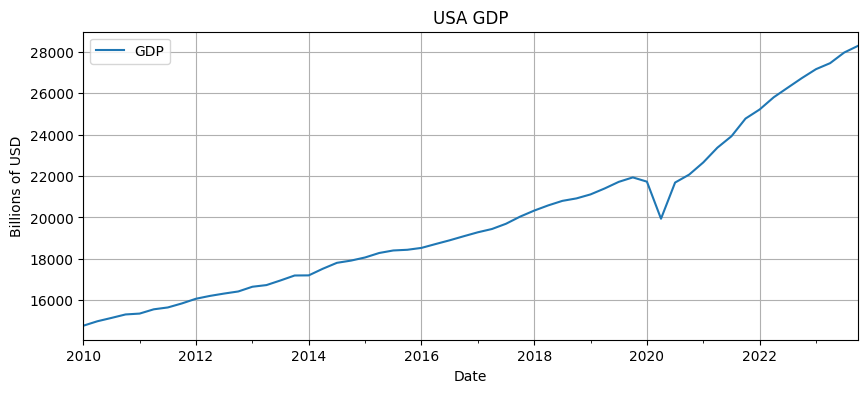

In [41]:
gdp.plot(figsize=(10, 4))
plt.title('USA GDP')
plt.xlabel('Date')
plt.ylabel('Billions of USD')
plt.grid(True)

## **Table 119. Autocorrelation plot**

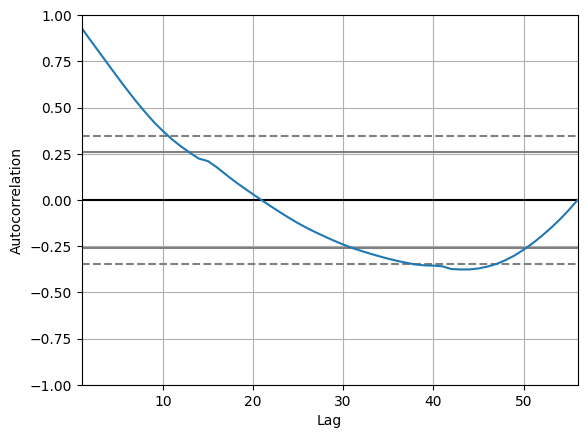

In [42]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(gdp)
plt.show()

## **Table 120. Stationarize data**

In [43]:
from tabulate import tabulate
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(gdp)

table_data = []
stationary = 'Yes' if adf_result[1] <= 0.05 else 'No'
table_data.append([
    'gdp',
    adf_result[0],
    adf_result[1],
    stationary])

headers = ['Variable', 'ADF Statistic', 'p-value', 'Stationary']
table = tabulate(table_data, headers=headers, tablefmt='fancy_grid')
print(table)

╒════════════╤═════════════════╤═══════════╤══════════════╕
│ Variable   │   ADF Statistic │   p-value │ Stationary   │
╞════════════╪═════════════════╪═══════════╪══════════════╡
│ gdp        │         1.76479 │  0.998277 │ No           │
╘════════════╧═════════════════╧═══════════╧══════════════╛


In [44]:
gdp_diff = np.log(gdp).diff().dropna()
adf_result = adfuller(gdp_diff)

table_data = []
stationary = 'Yes' if adf_result[1] <= 0.05 else 'No'
table_data.append([
    'gdp_diff',
    adf_result[0],
    adf_result[1],
    stationary])

headers = ['Variable', 'ADF Statistic', 'p-value', 'Stationary']
table = tabulate(table_data, headers=headers, tablefmt='fancy_grid')
print(table)

╒════════════╤═════════════════╤════════════╤══════════════╕
│ Variable   │   ADF Statistic │    p-value │ Stationary   │
╞════════════╪═════════════════╪════════════╪══════════════╡
│ gdp_diff   │         -8.7093 │ 3.6276e-14 │ Yes          │
╘════════════╧═════════════════╧════════════╧══════════════╛


## **Table 121. Auto ARIMA to identify optimal parameters (p & q)**

In [ ]:
pip install pmdarima

In [46]:
import pmdarima as pm
from pmdarima.arima import auto_arima

auto_model = auto_arima(
    gdp,
    start_p=0, start_q=0,
    # max_p=5, max_q=5,
    seasonal=True,
    m=4,
    stepwise=True,
    suppress_warnings=True,
    trace=True)

print(f"Optimal ARIMA Order: {auto_model.order}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[4] intercept   : AIC=inf, Time=0.37 sec
 ARIMA(0,1,0)(0,0,0)[4] intercept   : AIC=815.285, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[4] intercept   : AIC=818.868, Time=0.10 sec
 ARIMA(0,1,1)(0,0,1)[4] intercept   : AIC=818.903, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[4]             : AIC=832.021, Time=0.03 sec
 ARIMA(0,1,0)(1,0,0)[4] intercept   : AIC=817.269, Time=0.10 sec
 ARIMA(0,1,0)(0,0,1)[4] intercept   : AIC=817.262, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[4] intercept   : AIC=816.877, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[4] intercept   : AIC=816.910, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[4] intercept   : AIC=818.918, Time=0.11 sec

Best model:  ARIMA(0,1,0)(0,0,0)[4] intercept
Total fit time: 1.386 seconds
Optimal ARIMA Order: (0, 1, 0)


## **Table 122. Fitting an ARIMA(0, 0, 0) model to differenced GDP data**

In [47]:
from statsmodels.tsa.arima.model import ARIMA

arma_model = ARIMA(gdp_diff, order=(0, 0, 0))
arma_results = arma_model.fit()
print(arma_results.summary())

                               SARIMAX Results                                
Dep. Variable:                    GDP   No. Observations:                   55
Model:                          ARIMA   Log Likelihood                 143.187
Date:                Thu, 19 Dec 2024   AIC                           -282.374
Time:                        04:26:27   BIC                           -278.359
Sample:                    04-01-2010   HQIC                          -280.821
                         - 10-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0118      0.003      4.518      0.000       0.007       0.017
sigma2         0.0003   2.08e-05     15.378      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   2.02   Jarque-

## **Table 123. Residuals diagnostics through visualization**

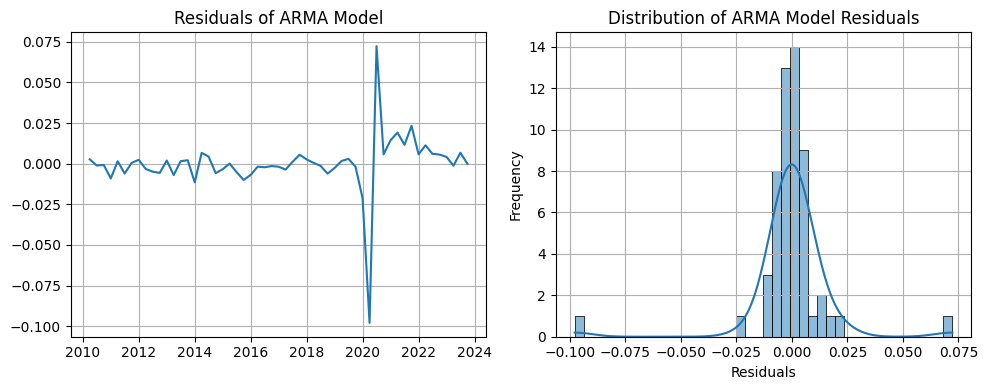

In [48]:
import seaborn as sns

arma_residuals = arma_results.resid

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1: Residuals plot
axes[0].plot(arma_residuals)
axes[0].set_title('Residuals of ARMA Model')
axes[0].grid()

# Plot 2: Histogram
sns.histplot(arma_residuals, kde=True, ax=axes[1])  # kde=True adds a kernel density estimate
axes[1].set_title('Distribution of ARMA Model Residuals')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## **Table 124. LjungBox and BoxPierce tests for residuals**

In [49]:
from statsmodels.stats.diagnostic import acorr_ljungbox

print('Ljungbox_test')
ljungbox_test = acorr_ljungbox(arma_residuals.dropna(), return_df=True)
print(ljungbox_test)
print('--------------------------------')
print('Boxpierce test')
boxpierce_test = acorr_ljungbox(arma_residuals.dropna(), boxpierce=True, return_df=True)
print(boxpierce_test)

Ljungbox_test
     lb_stat  lb_pvalue
1   2.016147   0.155634
2   2.032436   0.361961
3   2.076226   0.556737
4   2.130348   0.711799
5   2.425168   0.787720
6   2.731958   0.841658
7   2.731965   0.908642
8   2.951018   0.937394
9   3.040142   0.962682
10  3.127462   0.978263
--------------------------------
Boxpierce test
     lb_stat  lb_pvalue   bp_stat  bp_pvalue
1   2.016147   0.155634  1.910034   0.166959
2   2.032436   0.361961  1.925180   0.381902
3   2.076226   0.556737  1.965129   0.579676
4   2.130348   0.711799  2.013553   0.733266
5   2.425168   0.787720  2.272168   0.810346
6   2.731958   0.841658  2.535900   0.864428
7   2.731965   0.908642  2.535905   0.924369
8   2.951018   0.937394  2.716528   0.950869
9   3.040142   0.962682  2.788453   0.972095
10  3.127462   0.978263  2.857390   0.984584


In [50]:
from statsmodels.stats.diagnostic import acorr_ljungbox

boxpierce_test = acorr_ljungbox(arma_residuals.dropna(), boxpierce=True, return_df=True)
print(boxpierce_test)

     lb_stat  lb_pvalue   bp_stat  bp_pvalue
1   2.016147   0.155634  1.910034   0.166959
2   2.032436   0.361961  1.925180   0.381902
3   2.076226   0.556737  1.965129   0.579676
4   2.130348   0.711799  2.013553   0.733266
5   2.425168   0.787720  2.272168   0.810346
6   2.731958   0.841658  2.535900   0.864428
7   2.731965   0.908642  2.535905   0.924369
8   2.951018   0.937394  2.716528   0.950869
9   3.040142   0.962682  2.788453   0.972095
10  3.127462   0.978263  2.857390   0.984584


## **Table 125. Forecast out of sample 10 steps ahead**

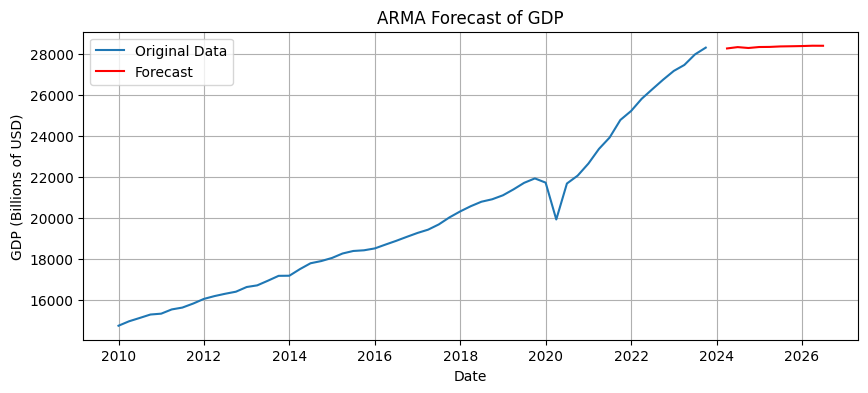

In [51]:
n = 10
forecast_diff = results.forecast(steps=n)
forecast_index = pd.date_range(start=gdp.index[-1], periods=n + 1, freq='QE')[1:]

forecast_log = forecast_diff.cumsum() + np.log(gdp['GDP'].iloc[-1])
forecast = np.exp(forecast_log)

plt.figure(figsize=(10, 4))
plt.plot(gdp.index, gdp['GDP'], label='Original Data')
plt.plot(forecast_index, forecast, label='Forecast', color='red')
plt.xlabel('Date')
plt.ylabel('GDP (Billions of USD)')
plt.title('ARMA Forecast of GDP')
plt.legend()
plt.grid(True)
plt.show()

## **Table 126. Manual grid search for optimal (p,d,q) values**

In [52]:
import itertools
p_values = range(0, 3)
d_values = [1]
q_values = range(0, 3)

best_aic = float('inf')
best_order = None

for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(gdp, order = (p, d, q))
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = (p, d, q)
    except:
        continue

print(f"Best ARIMA order: {best_order}, AIC: {best_aic}")


Best ARIMA order: (1, 1, 1), AIC: 819.301045456819


## **Table 127. ARIMA model with the best order of p, q, d**

In [53]:
model = ARIMA(gdp, order = (1,1,1))
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                    GDP   No. Observations:                   56
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -406.651
Date:                Thu, 19 Dec 2024   AIC                            819.301
Time:                        04:26:38   BIC                            825.323
Sample:                    01-01-2010   HQIC                           821.630
                         - 10-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.002    519.109      0.000       0.996       1.004
ma.L1         -0.9971      0.072    -13.943      0.000      -1.137      -0.857
sigma2      1.516e+05   4.84e-07   3.13e+11      0.0

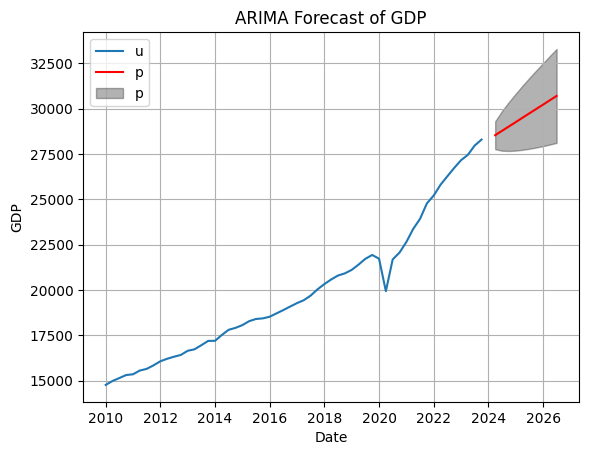

In [54]:
n = 10
forecast = results.get_forecast(steps=n)
forecast_values = forecast.predicted_mean
forecast_conf_int = forecast.conf_int()


forecast_index = pd.date_range(start=gdp.index[-1], periods=n + 1, freq='QE')[1:]
plt.plot(gdp.index, gdp['GDP'], label='Original Data')
plt.plot(forecast_index, forecast_values, label='Forecast', color='red')
plt.fill_between(forecast_index, forecast_conf_int.iloc[:, 0], forecast_conf_int.iloc[:, 1], color='k', alpha=0.3, label='Confidence Interval')
plt.xlabel('Date')
plt.ylabel('GDP')
plt.title('ARIMA Forecast of GDP')
plt.legend('upper left')
plt.grid(True)
plt.show()

## **Table 129. Rolling forecast implementation on Henry Hub natural gas data**

In [55]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

# Get Henry Hub natural gas data from FRED
start_date = '2010-01-01'
end_date = '2023-12-31'
henryhub_data = web.DataReader('DHHNGSP', 'fred', start_date, end_date)
henryhub_data.reset_index(inplace=True)
henryhub_data.columns = ['Date', 'Price']
henryhub_data.set_index('Date', inplace=True)

split_index = int(len(henryhub_data) * 0.9)  # 90% for training
train = henryhub_data[:split_index]
test = henryhub_data[split_index:]

print("Train data shape:", train.shape)
print("Test data shape:", test.shape)

Train data shape: (3285, 1)
Test data shape: (366, 1)


In [62]:
train.dropna(inplace=True)
test.dropna(inplace=True)

In [63]:
import itertools
p_values = range(0, 3)
d_values = [1]
q_values = range(0, 3)

best_aic = float('inf')
best_order = None

for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(train, order = (p, d, q))
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = (p, d, q)
    except:
        continue

print(f"Best ARIMA order: {best_order}, AIC: {best_aic}")

Best ARIMA order: (2, 1, 2), AIC: 3113.1454543736436


In [64]:
history = train['Price'].tolist()
predictions = []  # Initialize predictions as an empty list

# Rolling forecasts
for i in range(len(test)):  # Iterate over the entire length of test data
    model = ARIMA(history, order=best_order)
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    history.append(test['Price'].iloc[i])
    print(f"Iteration: {i + 1}, Original: {test['Price'].iloc[i]}, Predicted: {yhat}")

# Calculate performance metrics
mse = mean_squared_error(test['Price'], predictions)
mae = mean_absolute_error(test['Price'], predictions)
rmse = math.sqrt(mse)
print('MSE:', mse)
print('MAE:', mae)
print('RMSE:', rmse)

Iteration: 1, Original: 8.3, Predicted: 8.294460882240031
Iteration: 2, Original: 7.76, Predicted: 8.181238920021594
Iteration: 3, Original: 7.87, Predicted: 7.807138818069715
Iteration: 4, Original: 7.86, Predicted: 7.92802933183547
Iteration: 5, Original: 8.53, Predicted: 7.871618257111695
Iteration: 6, Original: 8.73, Predicted: 8.43886315816541
Iteration: 7, Original: 8.62, Predicted: 8.500002566224516
Iteration: 8, Original: 9.28, Predicted: 8.490928794009392
Iteration: 9, Original: 9.51, Predicted: 9.013487708164899
Iteration: 10, Original: 9.42, Predicted: 9.15973122259934
Iteration: 11, Original: 9.14, Predicted: 9.149756771715035
Iteration: 12, Original: 9.85, Predicted: 8.954425920612369
Iteration: 13, Original: 9.75, Predicted: 9.587678915559458
Iteration: 14, Original: 9.27, Predicted: 9.418250436015013
Iteration: 15, Original: 9.47, Predicted: 9.1717249739689
Iteration: 16, Original: 9.48, Predicted: 9.337561836846259
Iteration: 17, Original: 9.24, Predicted: 9.34113463594

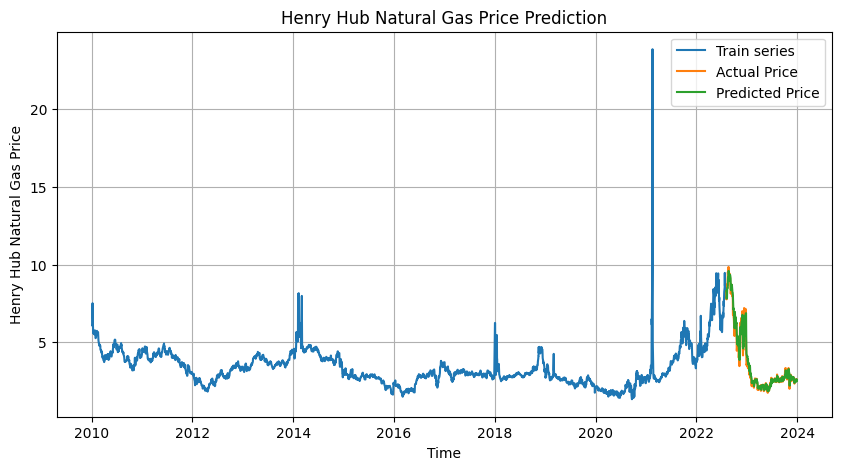

In [65]:
plt.figure(figsize=(10, 5))
plt.plot(train.index, train['Price'], label='Train series')
plt.plot(test.index, test['Price'], label='Actual Price')
plt.plot(test.index, predictions, label='Predicted Price')
plt.title('Henry Hub Natural Gas Price Prediction')
plt.xlabel('Time')
plt.ylabel('Henry Hub Natural Gas Price')
plt.legend()
plt.grid(True)
plt.show()